# PF spatial mapping, annotation, and marker validation

This notebook reproduces the data-driven results in UniGeneX manuscript **Figure 3E–H**. It first projects a spatial UGE query onto the PF atlas UMAP and then uses three Xenium samples to illustrate epithelial, endothelial, and fibroblast annotations:

- **Figure 3E:** spatial UGE cells from `VUILD107MA` mapped onto the disease-atlas UMAP;
- **Figure 3F:** epithelial cell states in unaffected sample `VUHD116A`;
- **Figure 3G:** endothelial cell states in IPF sample `VUILD107MA`;
- **Figure 3H:** fibroblast and mural cell states in IPF sample `VUILD106MA`.

By default, the notebook reads mappings generated by `transformer_map_to_atlas.sh`. Set `RUN_MAPPING = True` below to run the same `AtlasMapper` workflow interactively before continuing to the figures.

## Position in the PF workflow

Notebook 01 introduces the PF UGE atlas and its cell-type annotations. Notebook 02 documents how condition-specific normal and disease references were prepared. The mapping step can be run either with the shell launcher (recommended for the full dataset) or in the optional notebook cell below. The remaining cells read the saved mappings, visualize the spatial query in the atlas coordinate system, and return the transferred labels to the original Xenium coordinate system.

The mapping and marker panels use two complementary representations of the same cells:

1. The **UGE query** is used for cross-platform atlas mapping.
2. The **original log-normalized Xenium expression** is used to show measured canonical markers as a biological check on the transferred annotations.

Thus, marker concordance supports the biological plausibility of the mapping, while the marker genes themselves are not used to assign the displayed atlas labels.

## Data contract

Download and extract the modular archives from the [UniGeneX PF Zenodo record](https://doi.org/10.5281/zenodo.22489310). Set `UNIGENEX_DATA_DIR` to the extracted data directory containing `PF/`. If it is unset, the notebook looks for `./data/PF` relative to the working directory.

For each sample, the notebook requires:

| Input | Role |
|---|---|
| `PF/spatial_annotation/Reference_data/atlas_{Normal,Disease}.h5ad` | Condition-specific PF reference atlases; the disease-reference UMAP is displayed in Figure 3E |
| `PF/spatial_annotation/query_UGE/adata_inte_<sample>.h5ad` | Spatial UGE query used only when `RUN_MAPPING = True` |
| `PF/spatial_annotation/example_rerun_results/ct_anno_release_v1/<sample>/query_to_atlas_mapping.h5ad` | Saved cell-type labels, label probabilities, and query-to-atlas mapping |
| `PF/spatial_annotation/query_raw/<sample>_raw_log.h5ad` | Original log-normalized Xenium expression and spatial coordinates |

With the default `RUN_MAPPING = False`, the query UGE files are not loaded. Only observation metadata are read from the three saved mappings during spatial annotation; Figure 3E additionally materializes the compact VUILD107MA query-to-atlas connectivity matrix. The historical combined `adata_all.h5ad` is not required. Only the eight manuscript marker genes are materialized from the original Xenium files. Generated figures and tables are written to `outputs/03_spatial_annotation_results/` by default; set `UNIGENEX_OUTPUT_DIR` to select another location.

## Key parameters

The notebook defaults to loading mapping results produced by the shell launcher. This keeps the documentation quick to open while retaining an optional Python-API route for interactive use.

| Parameter | Default | Meaning |
|---|---:|---|
| `UNIGENEX_DATA_DIR` | `./data` | Directory containing the extracted `PF/` data folder. |
| `UNIGENEX_OUTPUT_DIR` | `outputs/03_spatial_annotation_results` | Destination for Figures 3E–H and mapping summaries. |
| `RUN_MAPPING` | `False` | Load saved mappings. Set to `True` only to rerun the potentially long mapping step in the notebook. |
| `ATLAS_LABEL_COLUMN` | `ct_anno` | Reference-atlas annotation transferred to the Xenium query. |
| `n_neighbors` | `30` | Cosine-nearest atlas cells used for majority-vote annotation. |
| `CONFIDENCE_CUTOFF` | `0.5` | Display a label only when more than half of the labeled neighbors support it. This affects visualization, not the mapping matrix. |
| `SAMPLE_CONFIG` | three manuscript samples | Assigns the normal or disease reference, marker genes, and spatial crops to each panel. |

The reported confidence is a neighbor-vote fraction, not a calibrated probability. Crop coordinates reproduce the manuscript views and should be changed when analyzing another spatial sample.

In [1]:
from pathlib import Path
import os
import platform
import sys
import warnings

import anndata as ad
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import font_manager
import numpy as np
import pandas as pd
from scipy import sparse
import seaborn as sns

DATA_ROOT = Path(
    os.environ.get("UNIGENEX_DATA_DIR", Path.cwd() / "data")
).expanduser().resolve()
PF_SPATIAL_DIR = DATA_ROOT / "PF" / "spatial_annotation"
REFERENCE_ROOT = PF_SPATIAL_DIR / "Reference_data"
NORMAL_REFERENCE_PATH = REFERENCE_ROOT / "atlas_Normal.h5ad"
DISEASE_REFERENCE_PATH = REFERENCE_ROOT / "atlas_Disease.h5ad"
QUERY_UGE_ROOT = PF_SPATIAL_DIR / "query_UGE"
NORMAL_INDEX_PATH = PF_SPATIAL_DIR / "fitted_reference_nn_normal"
DISEASE_INDEX_PATH = PF_SPATIAL_DIR / "fitted_reference_nn_disease"
MAPPING_ROOT = (
    PF_SPATIAL_DIR / "example_rerun_results" / "ct_anno_release_v1"
)
RAW_ROOT = PF_SPATIAL_DIR / "query_raw"

OUTPUT_DIR = Path(
    os.environ.get(
        "UNIGENEX_OUTPUT_DIR",
        Path.cwd() / "outputs" / "03_spatial_annotation_results",
    )
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Full mappings are best run from the shell. Change this only for an
# interactive mapping run in the notebook.
RUN_MAPPING = False
ATLAS_LABEL_COLUMN = "ct_anno"
LABEL_COLUMN = f"predict_mapped_{ATLAS_LABEL_COLUMN}"
PROBABILITY_COLUMN = f"{LABEL_COLUMN}_prob"
CONFIDENCE_CUTOFF = 0.5

# Locate the local UniGeneX package from the repository root or a nested
# notebook directory such as docs/vignettes/PF.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "UniGeneX" / "mapping.py").is_file():
        VALIDATION_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the UniGeneX package.")
if str(VALIDATION_ROOT) not in sys.path:
    sys.path.insert(0, str(VALIDATION_ROOT))

from UniGeneX.mapping import (
    AtlasMapper,
    align_atlas_to_mapping,
    load_mapping_result,
)
from UniGeneX.plotting import plot_atlas_projection

SAMPLE_CONFIG = {
    "VUHD116A": {
        "condition": "Unaffected",
        "figure": "3F",
        "mapping_subdir": "VUHD116A_Normal",
        "reference": "normal",
        "markers": ["SFTPC", "AGER", "TP63", "FOXJ1"],
        "crops": {
            "airway": (1450, 1950, 2000, 2400),
            "alveolar": (2150, 2450, 750, 1250),
        },
    },
    "VUILD107MA": {
        "condition": "IPF",
        "figure": "3G",
        "mapping_subdir": "VUILD107MA_Disease",
        "reference": "disease",
        "markers": ["HEY1", "CCL21"],
        "crops": {
            "arterial": (2000, 3500, 1750, 2800),
            "lymphatic": (800, 2000, 1900, 2800),
        },
    },
    "VUILD106MA": {
        "condition": "IPF",
        "figure": "3H",
        "mapping_subdir": "VUILD106MA_Disease",
        "reference": "disease",
        "markers": ["CTHRC1", "ACTA2"],
        "crops": {
            "fibrotic": (2000, 3500, 1000, 3000),
            "mural": (400, 1800, 1500, 4000),
        },
    },
}

required_files = [DISEASE_REFERENCE_PATH]
required_files.extend(
    RAW_ROOT / f"{sample}_raw_log.h5ad" for sample in SAMPLE_CONFIG
)
if RUN_MAPPING:
    required_files.append(NORMAL_REFERENCE_PATH)
    required_files.extend(
        QUERY_UGE_ROOT / f"adata_inte_{sample}.h5ad"
        for sample in SAMPLE_CONFIG
    )
    for index_path in [NORMAL_INDEX_PATH, DISEASE_INDEX_PATH]:
        required_files.extend([
            index_path / "knnpickle_file",
            index_path / "atlas_pcs.npy",
            index_path / "pcs.npy",
            index_path / "neigh_ind_atlas.npy",
            index_path / "neigh_dist_atlas.npy",
        ])
else:
    required_files.extend(
        MAPPING_ROOT / config["mapping_subdir"] / "query_to_atlas_mapping.h5ad"
        for config in SAMPLE_CONFIG.values()
    )
missing_files = [path for path in required_files if not path.is_file()]
if missing_files:
    formatted = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "Missing PF spatial-annotation files:\n"
        f"{formatted}\n"
        "Set UNIGENEX_DATA_DIR to the directory containing PF/. "
        "With RUN_MAPPING=False, run transformer_map_to_atlas.sh first."
    )

print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Mapping mode: {'run in notebook' if RUN_MAPPING else 'load saved results'}")

Data root: /path/to/zenodo/extraction
Output directory: UniGeneX/Real_data_PF/outputs/03_spatial_annotation_results
Mapping mode: load saved results


## Generate the mappings (optional)

For the full PF datasets, the recommended reproducible route is the script launcher. First edit `DATA_ROOT` in `Real_data_PF/transformer_map_to_atlas.sh`, then run:

```bash
bash Real_data_PF/transformer_map_to_atlas.sh
```

It uses the same `AtlasMapper.load_index(...).map(...)` calls shown below and writes one compact query-to-atlas mapping per sample. Keeping `RUN_MAPPING = False` skips this potentially long step and loads those saved files. Set it to `True` only when you want to generate or replace the mappings interactively. The normal reference is fitted once and reused for VUHD116A; the disease reference is fitted once and reused for both IPF samples.

In [2]:
if RUN_MAPPING:
    reference_config = {
        "normal": (NORMAL_REFERENCE_PATH, NORMAL_INDEX_PATH),
        "disease": (DISEASE_REFERENCE_PATH, DISEASE_INDEX_PATH),
    }
    mappers = {}
    for reference_name, (atlas_path, index_path) in reference_config.items():
        atlas = ad.read_h5ad(atlas_path)
        mappers[reference_name] = AtlasMapper(
            atlas, ATLAS_LABEL_COLUMN, n_neighbors=30
        ).load_index(index_path)

    for sample, config in SAMPLE_CONFIG.items():
        query = ad.read_h5ad(QUERY_UGE_ROOT / f"adata_inte_{sample}.h5ad")
        mapping = mappers[config["reference"]].map(query)
        output_path = (
            MAPPING_ROOT / config["mapping_subdir"]
            / "query_to_atlas_mapping.h5ad"
        )
        output_path.parent.mkdir(parents=True, exist_ok=True)
        mapping.write_h5ad(output_path)
        print(f"Saved {sample}: {output_path}")

    del atlas, query, mapping, mappers
else:
    print("Using precomputed mappings from transformer_map_to_atlas.sh.")

Using precomputed mappings from transformer_map_to_atlas.sh.


## Load and align the mapping results

For every query cell, the mapper reports a majority-vote atlas label and the fraction of its 30 cosine-nearest atlas neighbors that support that label. The mapping output retains the original Xenium barcode in `cell_id_y`. We use that barcode to join the transferred labels to the original Xenium object, avoiding assumptions about row order or generated identifiers such as `dataset_0_123`.

Following the original analysis, a label is displayed only when its support is greater than 0.5. Lower-confidence cells remain unassigned. This prevents a weak plurality among neighboring atlas cells from being presented as a confident annotation.

In [3]:
def load_sample(sample, config):
    mapping_path = (
        MAPPING_ROOT / config["mapping_subdir"] / "query_to_atlas_mapping.h5ad"
    )
    raw_path = RAW_ROOT / f"{sample}_raw_log.h5ad"

    # Backed mode leaves the query-by-atlas connectivity matrix on disk.
    mapping = load_mapping_result(
        mapping_path, expected_neighbors=30, backed="r"
    )
    required_mapping_columns = {
        "cell_id_y", LABEL_COLUMN, PROBABILITY_COLUMN
    }
    missing = required_mapping_columns.difference(mapping.obs.columns)
    if missing:
        mapping.file.close()
        raise KeyError(
            f"{mapping_path} is missing mapping columns: {sorted(missing)}"
        )

    mapping_parameters = dict(mapping.uns.get("mapping_parameters", {}))
    mapping_obs = mapping.obs[
        ["cell_id_y", LABEL_COLUMN, PROBABILITY_COLUMN]
    ].copy()
    mapping.file.close()

    mapping_obs["cell_id_y"] = mapping_obs["cell_id_y"].astype(str)
    if mapping_obs["cell_id_y"].duplicated().any():
        raise ValueError(f"Duplicated Xenium barcodes in mapping output for {sample}.")
    mapping_obs = mapping_obs.set_index("cell_id_y")
    mapping_obs.index.name = None

    # The original file contains log-normalized measured Xenium expression.
    raw = ad.read_h5ad(raw_path, backed="r")
    required_raw_columns = {"x_centroid", "y_centroid"}
    missing = required_raw_columns.difference(raw.obs.columns)
    if missing:
        raw.file.close()
        raise KeyError(f"{raw_path} is missing spatial columns: {sorted(missing)}")

    missing_genes = sorted(set(config["markers"]).difference(raw.var_names))
    if missing_genes:
        raw.file.close()
        raise KeyError(f"{raw_path} is missing marker genes: {missing_genes}")

    spatial_obs = raw.obs[["x_centroid", "y_centroid"]].copy()
    spatial_obs.index = spatial_obs.index.astype(str)
    marker_adata = raw[:, config["markers"]].to_memory()
    raw.file.close()

    marker_matrix = marker_adata.X
    if sparse.issparse(marker_matrix):
        marker_matrix = marker_matrix.toarray()
    marker_expression = pd.DataFrame(
        np.asarray(marker_matrix),
        index=marker_adata.obs_names.astype(str),
        columns=config["markers"],
    )

    spatial_obs = spatial_obs.join(
        mapping_obs[[LABEL_COLUMN, PROBABILITY_COLUMN]], how="left"
    )
    spatial_obs[PROBABILITY_COLUMN] = pd.to_numeric(
        spatial_obs[PROBABILITY_COLUMN], errors="coerce"
    )
    confident = spatial_obs[PROBABILITY_COLUMN] > CONFIDENCE_CUTOFF
    spatial_obs["display_label"] = pd.Series(
        pd.NA, index=spatial_obs.index, dtype="object"
    )
    spatial_obs.loc[confident, "display_label"] = (
        spatial_obs.loc[confident, LABEL_COLUMN].astype(str)
    )

    unmatched_mapping_cells = mapping_obs.index.difference(spatial_obs.index)
    if len(unmatched_mapping_cells):
        warnings.warn(
            f"{len(unmatched_mapping_cells):,} mapped {sample} cells could not be "
            "aligned to original Xenium barcodes."
        )

    return {
        "obs": spatial_obs,
        "marker_expression": marker_expression.reindex(spatial_obs.index),
        "mapping_parameters": mapping_parameters,
        "mapping_path": mapping_path,
        "raw_path": raw_path,
    }


samples = {
    sample: load_sample(sample, config)
    for sample, config in SAMPLE_CONFIG.items()
}
print("Loaded and barcode-aligned all three spatial examples.")

Loaded and barcode-aligned all three spatial examples.


## Mapping quality summary

The following table reports how many original Xenium cells received mapping results and how many passed the strict `> 0.5` majority-support threshold. This is a descriptive mapping summary rather than a ground-truth accuracy estimate. Cell-type counts are also saved so readers can inspect the composition behind each spatial panel.

In [4]:
summary_rows = []
count_tables = []
for sample, config in SAMPLE_CONFIG.items():
    obs = samples[sample]["obs"]
    mapped = obs[PROBABILITY_COLUMN].notna()
    confident = obs["display_label"].notna()
    summary_rows.append({
        "figure": config["figure"],
        "sample": sample,
        "condition": config["condition"],
        "xenium_cells": len(obs),
        "cells_with_mapping": int(mapped.sum()),
        "confident_cells": int(confident.sum()),
        "confident_fraction": float(confident.mean()),
    })

    counts = (
        obs.loc[confident, "display_label"]
        .value_counts()
        .rename_axis("predicted_cell_type")
        .rename("n_cells")
        .reset_index()
    )
    counts.insert(0, "sample", sample)
    count_tables.append(counts)

mapping_summary = pd.DataFrame(summary_rows)
predicted_celltype_counts = pd.concat(count_tables, ignore_index=True)
mapping_summary.to_csv(OUTPUT_DIR / "mapping_summary.csv", index=False)
predicted_celltype_counts.to_csv(
    OUTPUT_DIR / "predicted_celltype_counts.csv", index=False
)
display(mapping_summary.style.format({"confident_fraction": "{:.1%}"}))

,figure,sample,condition,xenium_cells,cells_with_mapping,confident_cells,confident_fraction
0,3F,VUHD116A,Unaffected,12372,12372,11025,89.1%
1,3G,VUILD107MA,IPF,68413,68413,60211,88.0%
2,3H,VUILD106MA,IPF,124717,124717,107406,86.1%


## Shared spatial plotting functions

These plotting functions intentionally retain the behavior of the original PF notebooks rather than replacing it with a new Matplotlib style. Annotation panels use `seaborn.scatterplot`, while measured marker expression uses `scanpy.pl.embedding`. Confidently mapped cells from the lineage of interest are drawn with manuscript-matched colors; other confidently mapped cell types form a light-gray tissue background. Spatial axes are hidden and the vertical axis is inverted because Xenium image coordinates increase from top to bottom.

Marker panels show original log-normalized Xenium values. Matching the source notebooks, all cells are drawn first and cells from the selected lineage are then overlaid using a color scale capped at the 99th percentile within the displayed region. Scanpy's continuous-value sorting keeps highly expressed cells above low-expression cells and avoids artificial crescent-shaped overlaps. Crop coordinates, figure dimensions, point sizes, alpha values, axis formatting, and the default 100-dpi notebook display are retained from the source notebooks.

In [5]:
BACKGROUND_COLOR = "#DEDEDE"
try:
    font_manager.findfont(
        font_manager.FontProperties(family="Arial"),
        fallback_to_default=False,
    )
    PF_FONT_FAMILY = "Arial"
except ValueError:
    PF_FONT_FAMILY = "DejaVu Sans"

ATLAS_CELL_TYPE_COLORS = {
    "AT1": "#FFFF00",
    "AT2": "#1CE6FF",
    "Aberrant Basaloid": "#FF34FF",
    "Alveolar Mph CCL3+": "#FF4A46",
    "Alveolar Mph proliferating": "#008941",
    "Alveolar macrophages": "#006FA6",
    "B cells": "#A30059",
    "Basal": "#FFD5E5",
    "Basal-Prolif": "#7A4900",
    "CD4 T cells": "#0000A6",
    "CD8 T cells": "#63FFAC",
    "Ciliated": "#B79762",
    "Ciliated MUC5AC+": "#004D43",
    "Ciliated SCGB3A2+": "#8FB0FF",
    "Classical monocytes": "#997D87",
    "DC1": "#5A0007",
    "DC2": "#809693",
    "EC aerocyte capillary": "#6A3A4C",
    "EC arterial": "#1B4400",
    "EC general capillary": "#4FC601",
    "EC venous systemic": "#3B5DFF",
    "FB": "#4A3B53",
    "FB COL1A1+": "#FF2F80",
    "FB ECM": "#61615A",
    "FB ECM CHI3L2+": "#BA0900",
    "FB ECM COL1A1+": "#6B7900",
    "FB ECM SOX4+": "#00C2A0",
    "FB HAS1+": "#0D841B",
    "Interstitial Mph perivascular": "#FF90C9",
    "Ionocyte": "#B903AA",
    "Lymphatic EC mature": "#D16100",
    "Mast cells": "#DDEFFF",
    "Mesothelial": "#000035",
    "Migratory DCs": "#7B4F4B",
    "Monocyte-derived Mph": "#A1C299",
    "NK cells": "#300018",
    "Neuroendocrine": "#0AA6D8",
    "Non-classical monocytes": "#013349",
    "Pericytes": "#00846F",
    "Plasma cells": "#372101",
    "Plasmacytoid DCs": "#FFB500",
    "SCGB1A1+/SCGB3A1+/SCGB3A2+": "#C2FFED",
    "SCGB3A1+/SCGB3A2+": "#A079BF",
    "SMCs": "#CC0744",
    "SMG duct": "#C0B9B2",
    "SMG-Serous": "#C2FF99",
    "Secretory MUC5AC+": "#001E09",
    "Secretory MUC5B+": "#00489C",
    "Smooth muscle": "#6F0062",
    "Squamous": "#0CBD66",
    "Suprabasal": "#EEC3FF",
    "Suprabasal SCGB1A1+": "#456D75",
    "myo-FB": "#B77B68",
}

EPITHELIAL_PALETTE = {
    "AT1": "#FFFF00",
    "AT2": "#1CE6FF",
    "Basal": "#B3303F",
    "Ciliated": "#5987F7",
    "SCGB3A1+/SCGB3A2+": "#B8D164",
    "SCGB1A1+/SCGB3A1+/SCGB3A2+": "#6B446E",
}
ENDOTHELIAL_PALETTE = {
    "EC aerocyte capillary": "#6A3A4C",
    "EC arterial": "#CF3940",
    "EC general capillary": "#C6BFED",
    "EC venous systemic": "#C9C03E",
    "Lymphatic EC mature": "#3B70D3",
    "SMCs": "#E4E4E4",
}
FIBROBLAST_PALETTE = {
    "FB": "#EF9ADF",
    "FB ECM": "#D03A40",
    "FB ECM SOX4+": "#69C9FA",
    "FB HAS1+": "#0D841B",
    "Mesothelial": "#000035",
    "Pericytes": "#A06923",
    "SMCs": "#A06923",
    "myo-FB": "#4F6EC6",
}


def set_pf_style(font=1.6, circle_marker=1.0):
    """Reset Matplotlib exactly as in the original PF plotting notebooks."""
    plt.rcParams.update(plt.rcParamsDefault)
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("seaborn-v0_8-whitegrid")
    sns.set_context("paper", font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams["font.family"] = PF_FONT_FAMILY


def select_crop(frame, bounds):
    x_min, x_max, y_min, y_max = bounds
    return frame.loc[
        frame["x_centroid"].between(x_min, x_max)
        & frame["y_centroid"].between(y_min, y_max)
    ].copy()


def show_annotation(
    obs, palette, filename, figsize, background_size, selected_size,
    selected_sizes=None, legend_items=None, legend_anchor=(1.4, 0.7),
    plot_order=None,
):
    """Reproduce the Seaborn annotation layers used in the PF notebooks."""
    set_pf_style(font=1.6, circle_marker=5)
    selected_sizes = selected_sizes or {}
    selected_lineage = obs["display_label"].isin(palette)
    background = obs.loc[~selected_lineage & obs["display_label"].notna()]

    fig, ax = plt.subplots(1, 1, figsize=figsize, gridspec_kw={
        "wspace": 0.2, "hspace": 0.3
    })
    if len(background):
        background_palette = {
            label: BACKGROUND_COLOR
            for label in background["display_label"].dropna().unique()
        }
        sns.scatterplot(
            data=background, x="x_centroid", y="y_centroid",
            hue="display_label", s=background_size, linewidth=0,
            ax=ax, palette=background_palette, alpha=0.9, legend=False,
        )

    if plot_order is None:
        plot_order = list(palette)
    unknown_types = set(plot_order).difference(palette)
    if unknown_types:
        raise KeyError(f"Plot order contains unknown cell types: {unknown_types}")

    for cell_type in plot_order:
        color = palette[cell_type]
        selected = obs.loc[obs["display_label"] == cell_type]
        if len(selected):
            sns.scatterplot(
                data=selected, x="x_centroid", y="y_centroid",
                hue="display_label",
                s=selected_sizes.get(cell_type, selected_size),
                linewidth=0.0, edgecolor="black", ax=ax,
                palette={cell_type: color}, alpha=0.9, legend=False,
            )

    for spine in ["left", "right", "top", "bottom"]:
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(obs["x_centroid"].min(), obs["x_centroid"].max())
    ax.set_ylim(obs["y_centroid"].min(), obs["y_centroid"].max())
    ax.invert_yaxis()
    ax.set_title("")

    if legend_items is None:
        legend_items = list(palette.items())
    handles = [Patch(facecolor=color) for _, color in legend_items]
    labels = [label for label, _ in legend_items]
    ax.legend(
        handles, labels, title="Cell types", fontsize=15,
        title_fontsize=25, bbox_to_anchor=legend_anchor,
        bbox_transform=fig.transFigure, loc="upper right",
    )
    fig.savefig(
        OUTPUT_DIR / filename, dpi=200, bbox_inches="tight", pad_inches=1
    )
    plt.show()
    plt.close(fig)


def show_marker(obs, expression, gene, palette, filename, point_size):
    """Reproduce the two Scanpy expression layers used in the PF notebooks."""
    set_pf_style(font=4.6, circle_marker=5)
    values = expression.loc[obs.index, gene].astype(float).to_numpy()
    marker_adata = ad.AnnData(
        X=values[:, None], obs=obs.copy(),
        var=pd.DataFrame(index=pd.Index([gene], name="gene")),
    )
    marker_adata.obsm["spatial"] = obs[[
        "x_centroid", "y_centroid"
    ]].to_numpy()
    selected = marker_adata.obs["display_label"].isin(palette)
    selected_adata = marker_adata[selected].copy()
    finite_values = values[np.isfinite(values)]
    vmax = float(np.quantile(finite_values, 0.99)) if len(finite_values) else 1.0
    if vmax <= 0:
        vmax = 1.0

    fig, ax = plt.subplots(1, 1, figsize=(12, 10), gridspec_kw={
        "wspace": 0.2, "hspace": 0.3
    })
    sc.pl.embedding(
        marker_adata, basis="spatial", color=gene, s=point_size,
        linewidth=0.0, edgecolor="black", ax=ax, cmap="viridis",
        alpha=1.0, vmax=1e10, colorbar_loc=None, sort_order=True,
        show=False, title="",
    )
    if selected_adata.n_obs:
        sc.pl.embedding(
            selected_adata, basis="spatial", color=gene, s=point_size,
            linewidth=0.0, edgecolor="black", ax=ax, cmap="viridis",
            alpha=1.0, vmax=vmax, sort_order=True, show=False, title="",
        )
    ax.invert_yaxis()
    for spine in ["left", "right", "top", "bottom"]:
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(2)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(gene, fontdict={"fontstyle": "italic"}, fontsize=70)
    fig.savefig(
        OUTPUT_DIR / filename, dpi=200, bbox_inches="tight", pad_inches=0.1
    )
    plt.show()
    plt.close(fig)

## Figure 3E — project spatial UGE cells onto the atlas UMAP

The VUILD107MA spatial UGE query is projected into the UMAP coordinates of the disease reference. This reproduces the cell-type-specific projection in the original `2_Example_sp_map_to_sc.ipynb`, but reads the query-to-atlas fuzzy connectivity matrix directly from `query_to_atlas_mapping.h5ad`; the large historical combined atlas/query object is unnecessary.

After applying the mapping-confidence cutoff, fuzzy-connectivity values below 0.5 are removed. For each atlas cell type, query cells with above-median positive connectivity to that type are placed at the connectivity-weighted mean of the corresponding atlas UMAP coordinates. The gray background is the disease atlas, while colored points are projected spatial cells. The atlas UMAP itself is not recomputed.

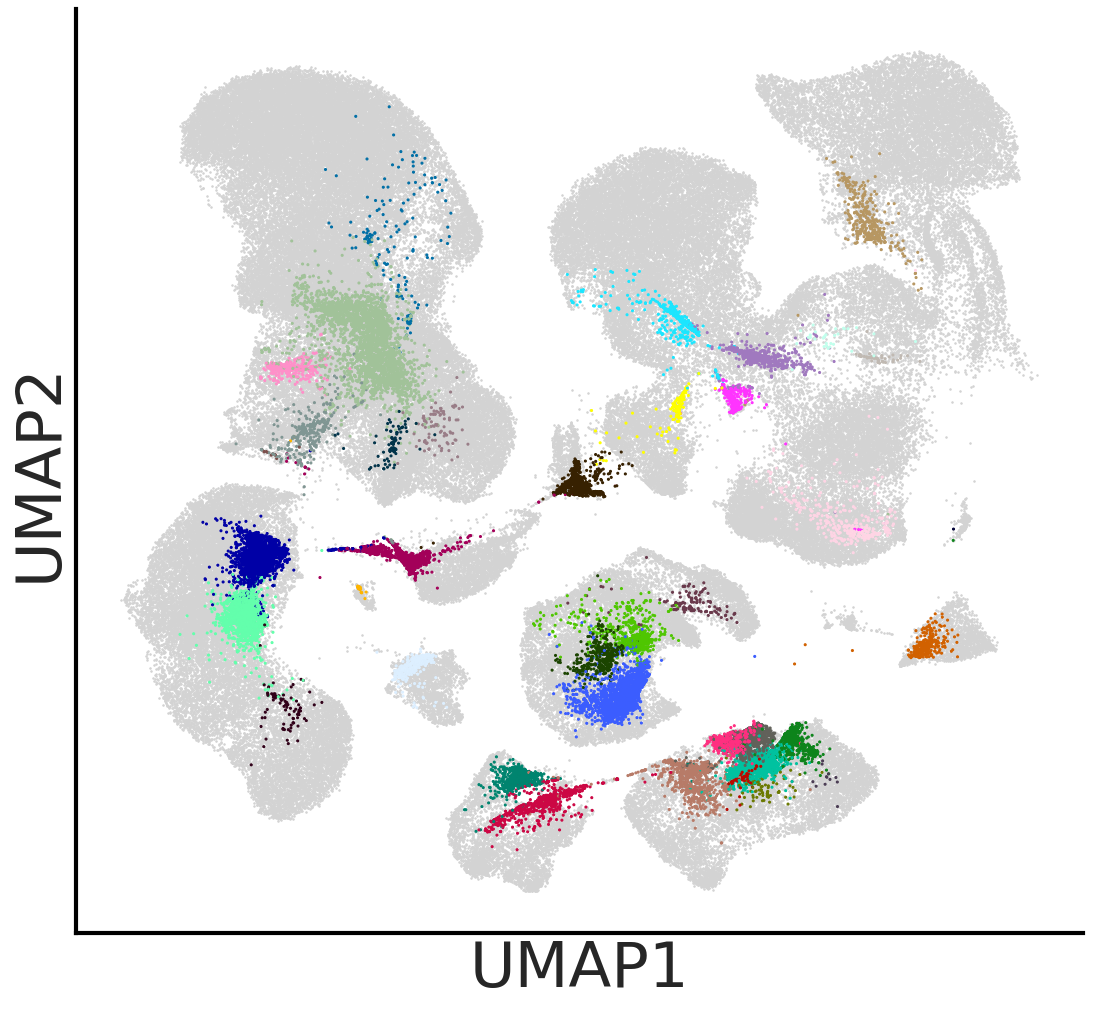

Projected 34,555 cell-type-specific points from 60,211 confidently mapped spatial cells.


In [6]:
figure3e_mapping_path = (
    MAPPING_ROOT / SAMPLE_CONFIG["VUILD107MA"]["mapping_subdir"]
    / "query_to_atlas_mapping.h5ad"
)
mapping_3e = load_mapping_result(
    figure3e_mapping_path, expected_neighbors=30
)
atlas_3e = ad.read_h5ad(DISEASE_REFERENCE_PATH, backed="r")

if "X_umap" not in atlas_3e.obsm:
    atlas_3e.file.close()
    raise KeyError("The disease reference is missing obsm['X_umap'].")
if "ct_anno" not in atlas_3e.obs:
    atlas_3e.file.close()
    raise KeyError("The disease reference is missing obs['ct_anno'].")

atlas_3e = align_atlas_to_mapping(atlas_3e, mapping_3e)
atlas_umap = np.asarray(atlas_3e.obsm["X_umap"])
atlas_labels = atlas_3e.obs[ATLAS_LABEL_COLUMN].astype(str).copy()
atlas_3e.file.close()

confident = (
    mapping_3e.obs[PROBABILITY_COLUMN].to_numpy() > CONFIDENCE_CUTOFF
)
mapping_3e = mapping_3e[confident].copy()
mapped_labels = mapping_3e.obs[LABEL_COLUMN].astype(str)

present_labels = pd.unique(atlas_labels).tolist()
atlas_palette = {
    label: ATLAS_CELL_TYPE_COLORS[label]
    for label in present_labels if label in ATLAS_CELL_TYPE_COLORS
}
missing_colors = [label for label in present_labels if label not in atlas_palette]
if missing_colors:
    fallback = sns.color_palette("husl", len(missing_colors)).as_hex()
    atlas_palette.update(dict(zip(missing_colors, fallback)))

query_colors = mapped_labels.map(atlas_palette).fillna("#666666").to_numpy()
set_pf_style(font=3)
fig, ax = plot_atlas_projection(
    mapping_3e,
    atlas_umap,
    atlas_labels,
    query_colors,
    groups=atlas_labels.value_counts().index,
    connectivity_threshold=0.5,
    display_quantile=0.5,
    atlas_size=1,
    query_size=2,
    figsize=(13, 12),
)
projected_points = sum(
    len(collection.get_offsets()) for collection in ax.collections[1:]
)

for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_visible(False)
    tick.tick2line.set_visible(False)
    tick.label1.set_visible(False)
    tick.label2.set_visible(False)
ax.set_yticks([])
ax.set_xlabel("UMAP1", fontsize=45)
ax.set_ylabel("UMAP2", fontsize=45)
ax.grid(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(3)
    ax.spines[spine].set_color("black")
fig.savefig(
    OUTPUT_DIR / "Figure3E_spatial_to_atlas_umap.png",
    dpi=200, bbox_inches="tight", pad_inches=1,
)
plt.show()
plt.close(fig)
print(
    f"Projected {projected_points:,} cell-type-specific points from "
    f"{confident.sum():,} confidently mapped spatial cells."
)

## Figure 3F — epithelial annotation in unaffected lung

`VUHD116A` is an unaffected lung sample. The full section highlights alveolar, airway, and secretory epithelial states. Two fixed regions are enlarged: an alveolar region is compared with measured `SFTPC` (AT2) and `AGER` (AT1) expression, while an airway region is compared with `TP63` (basal) and `FOXJ1` (ciliated) expression. Agreement between the spatial assignments and these canonical markers provides a direct check on the transferred epithelial identities.

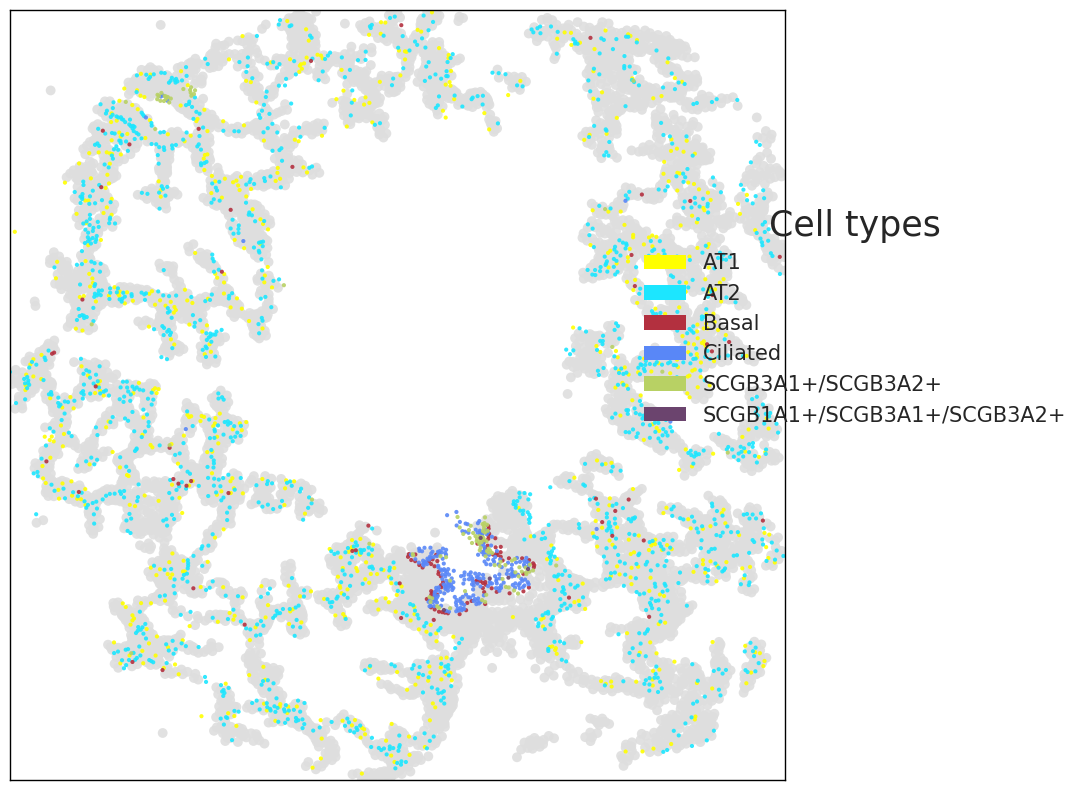

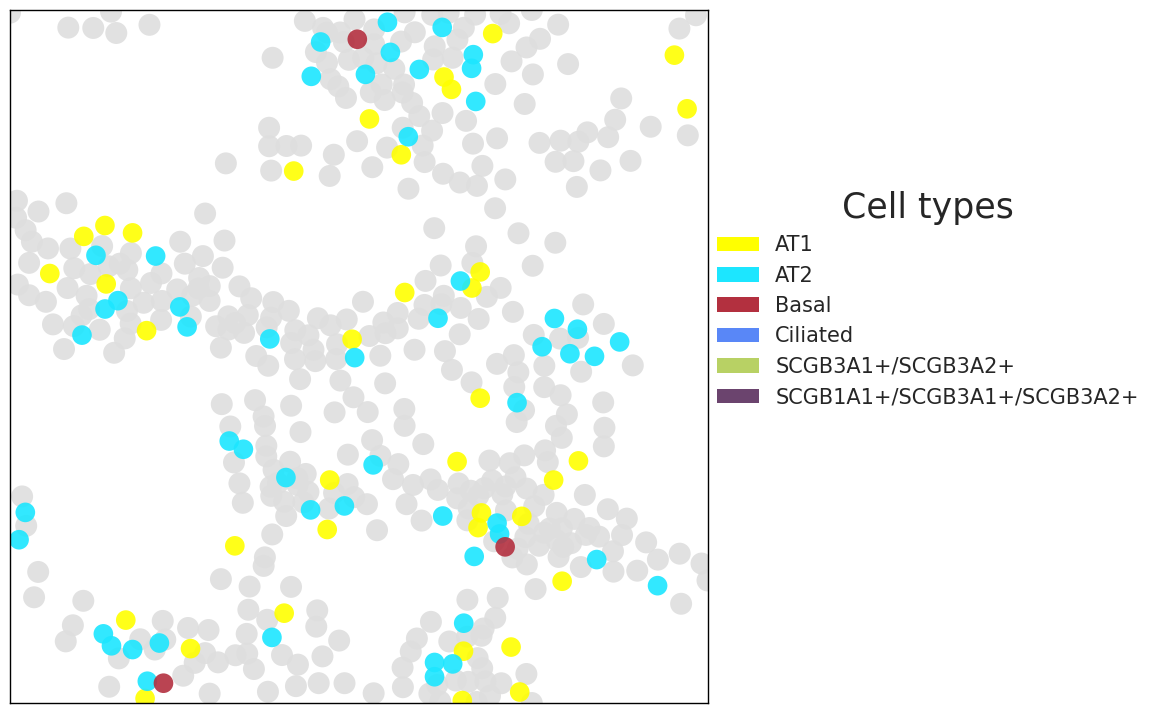

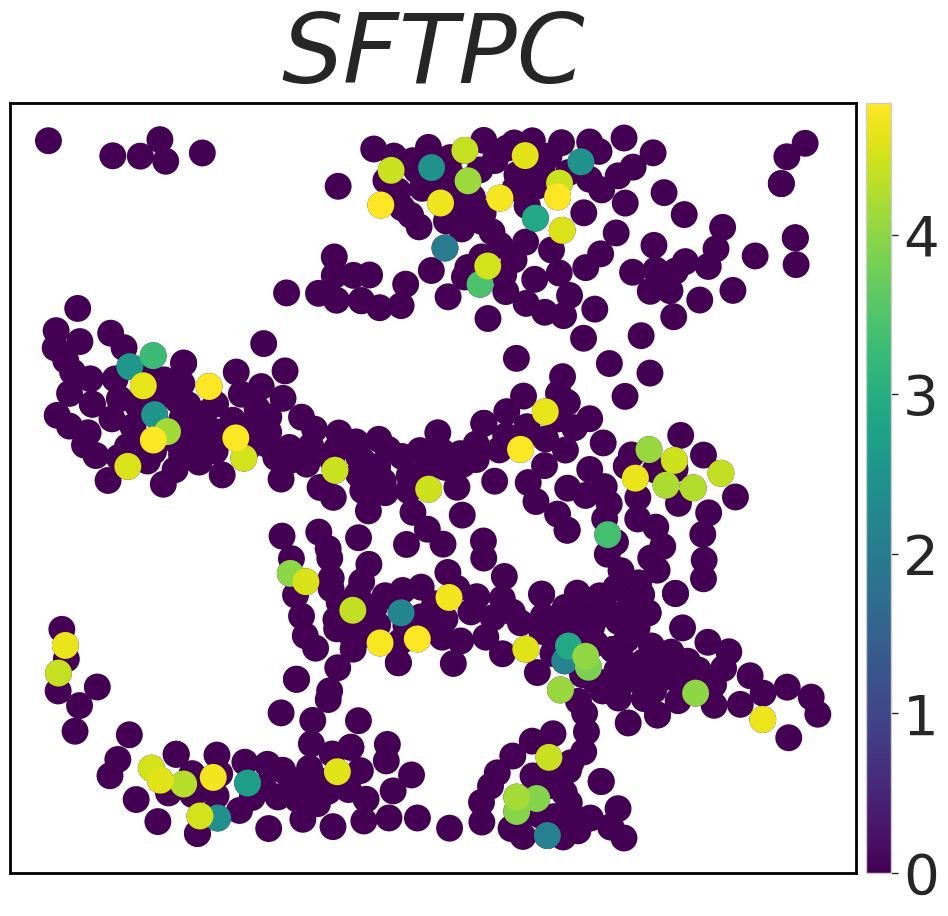

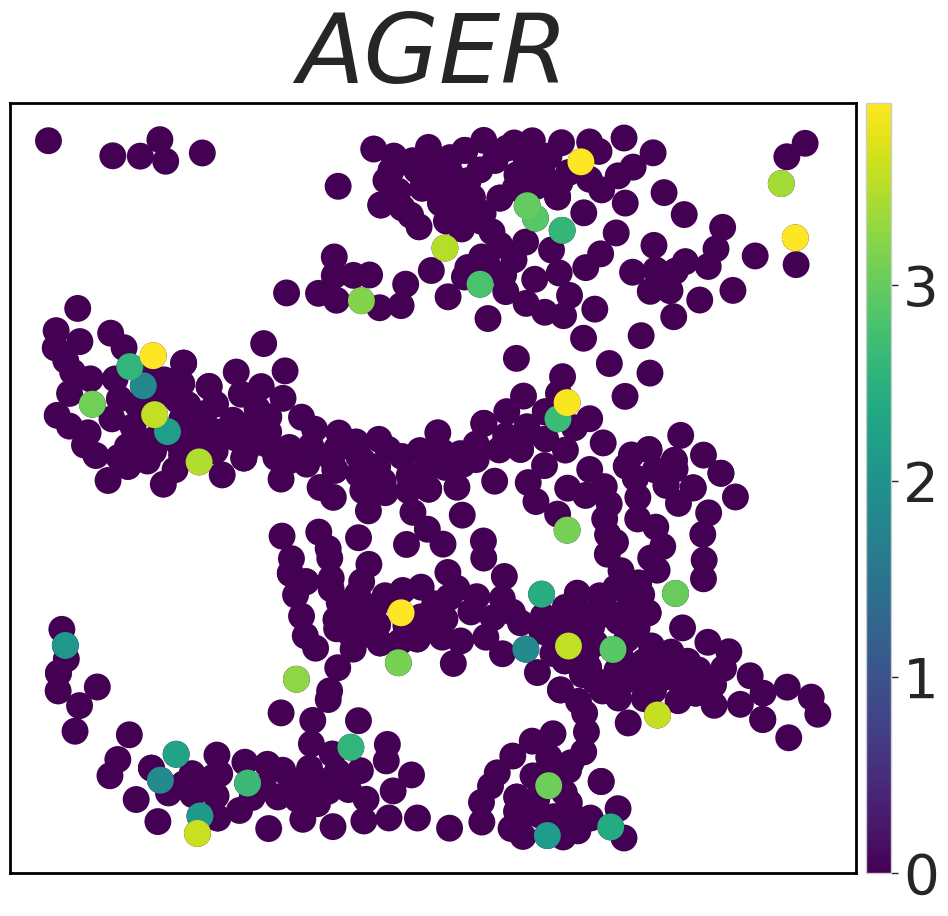

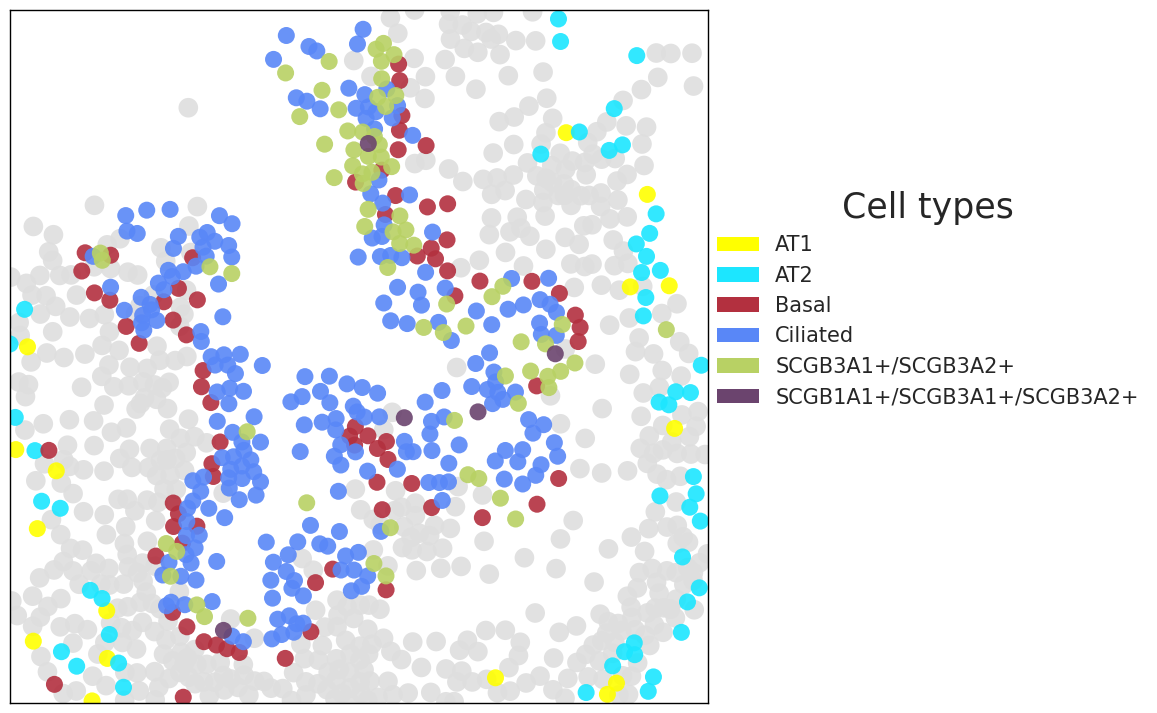

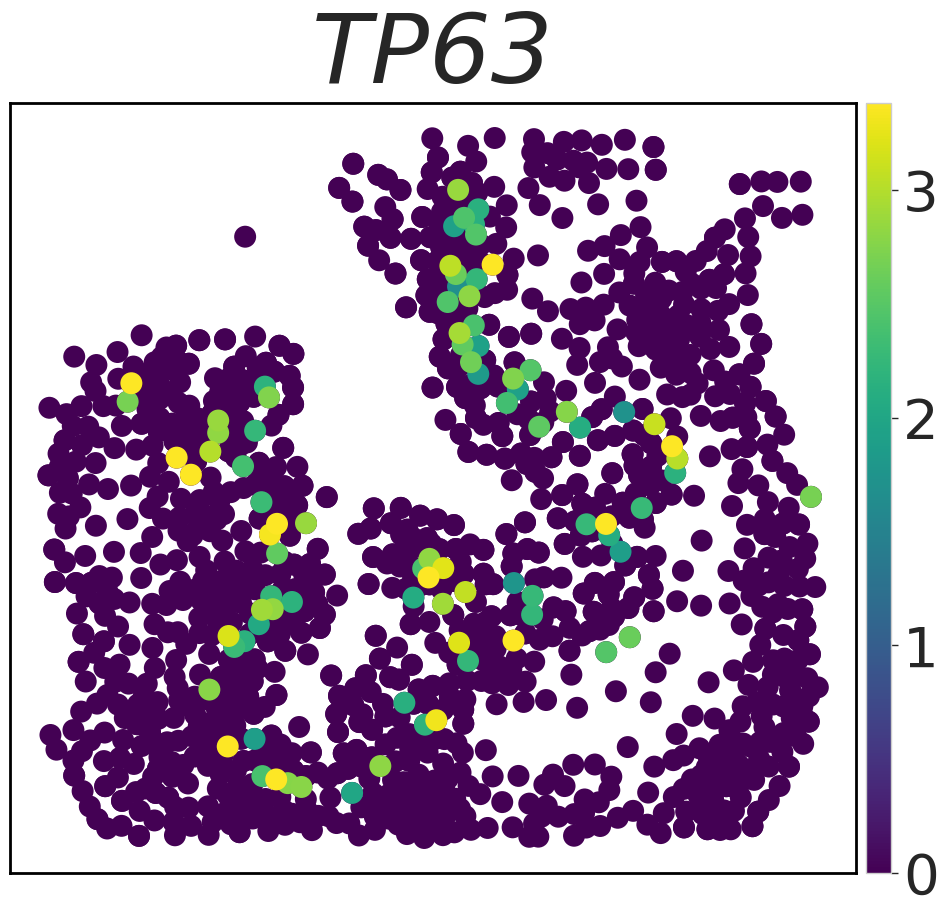

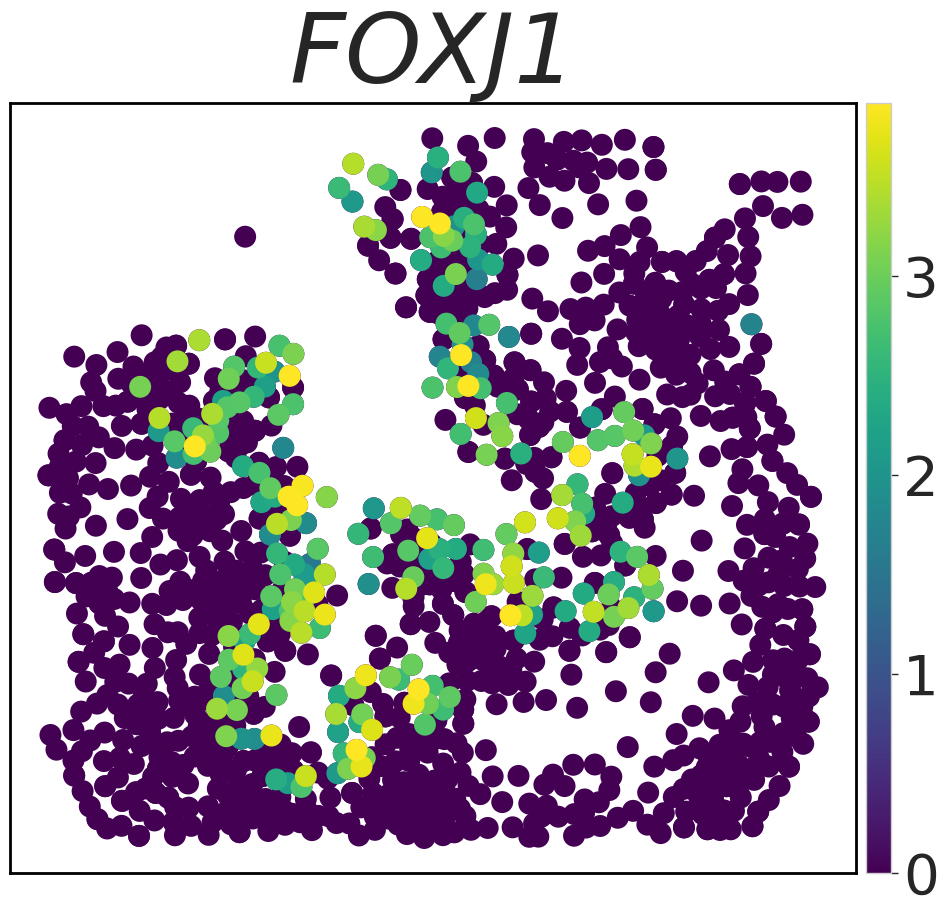

In [7]:
sample = "VUHD116A"
obs = samples[sample]["obs"]
expression = samples[sample]["marker_expression"]
alveolar = select_crop(obs, SAMPLE_CONFIG[sample]["crops"]["alveolar"])
airway = select_crop(obs, SAMPLE_CONFIG[sample]["crops"]["airway"])

show_annotation(
    obs, EPITHELIAL_PALETTE, "Figure3F_epithelial_full.png",
    (10, 10), 50, 9, legend_anchor=(1.2, 0.7),
)
show_annotation(
    alveolar, EPITHELIAL_PALETTE, "Figure3F_alveolar_annotation.png",
    (9, 9), 250, 200,
)
show_marker(
    alveolar, expression, "SFTPC", EPITHELIAL_PALETTE,
    "Figure3F_alveolar_SFTPC.png", 1500,
)
show_marker(
    alveolar, expression, "AGER", EPITHELIAL_PALETTE,
    "Figure3F_alveolar_AGER.png", 1500,
)
show_annotation(
    airway, EPITHELIAL_PALETTE, "Figure3F_airway_annotation.png",
    (9, 9), 200, 150,
)
show_marker(
    airway, expression, "TP63", EPITHELIAL_PALETTE,
    "Figure3F_airway_TP63.png", 1000,
)
show_marker(
    airway, expression, "FOXJ1", EPITHELIAL_PALETTE,
    "Figure3F_airway_FOXJ1.png", 1000,
)

## Figure 3G — endothelial annotation in IPF lung

`VUILD107MA` is an IPF sample containing spatially distinct vascular compartments. The full section highlights capillary, arterial, venous, and lymphatic endothelial states. The first selected region is compared with the arterial marker `HEY1`; the second is compared with the lymphatic marker `CCL21`. To keep the vessel structures visible where points overlap, light-gray SMCs are drawn below all endothelial populations, and the focal population (`EC arterial` or `Lymphatic EC mature`) is drawn last in its corresponding enlarged panel. These marker patterns test whether the atlas-derived labels recover expected vascular organization in diseased tissue.

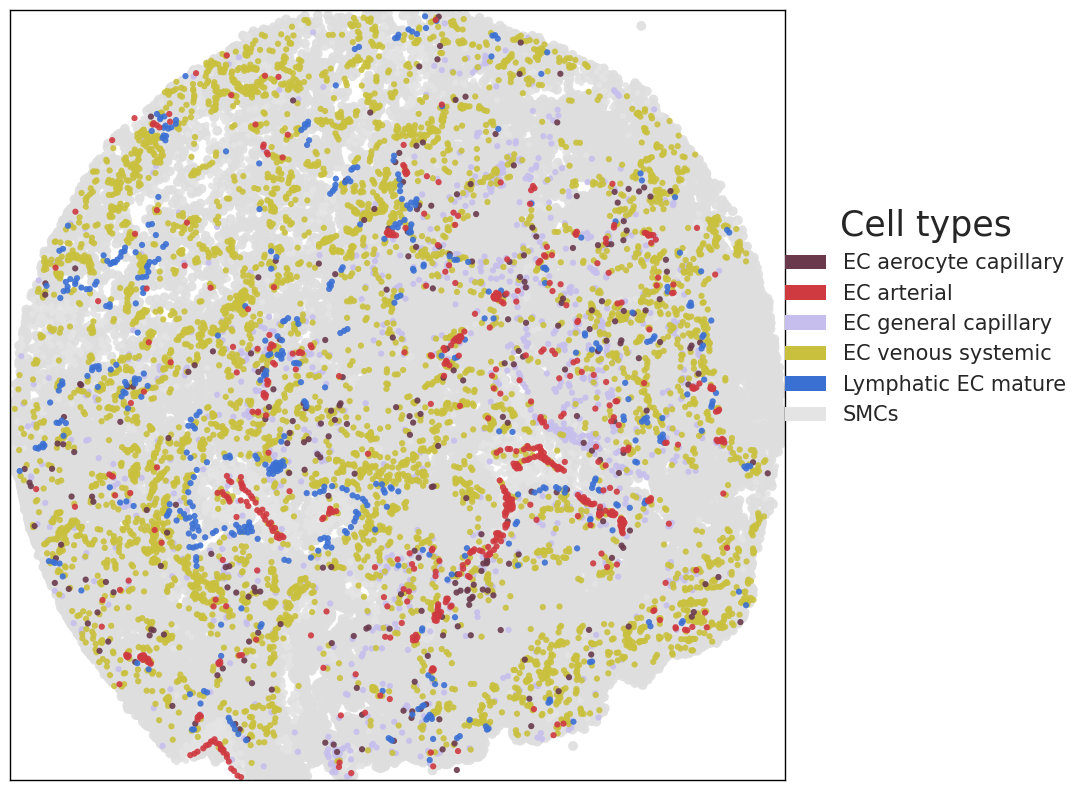

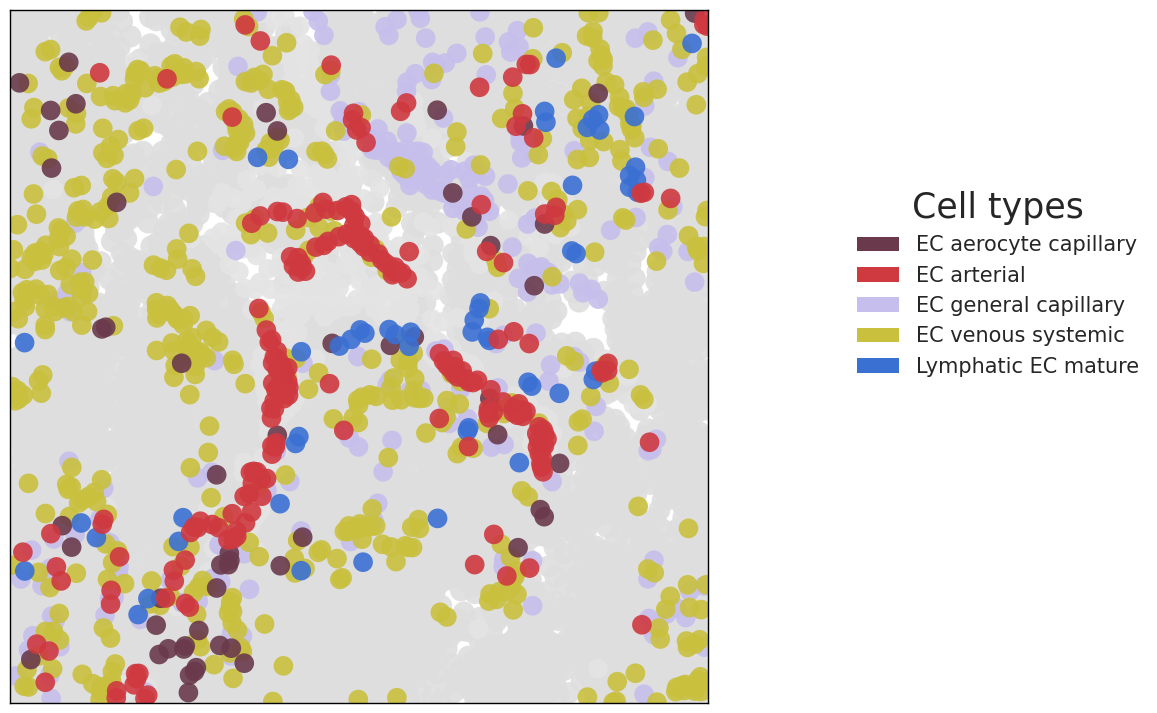

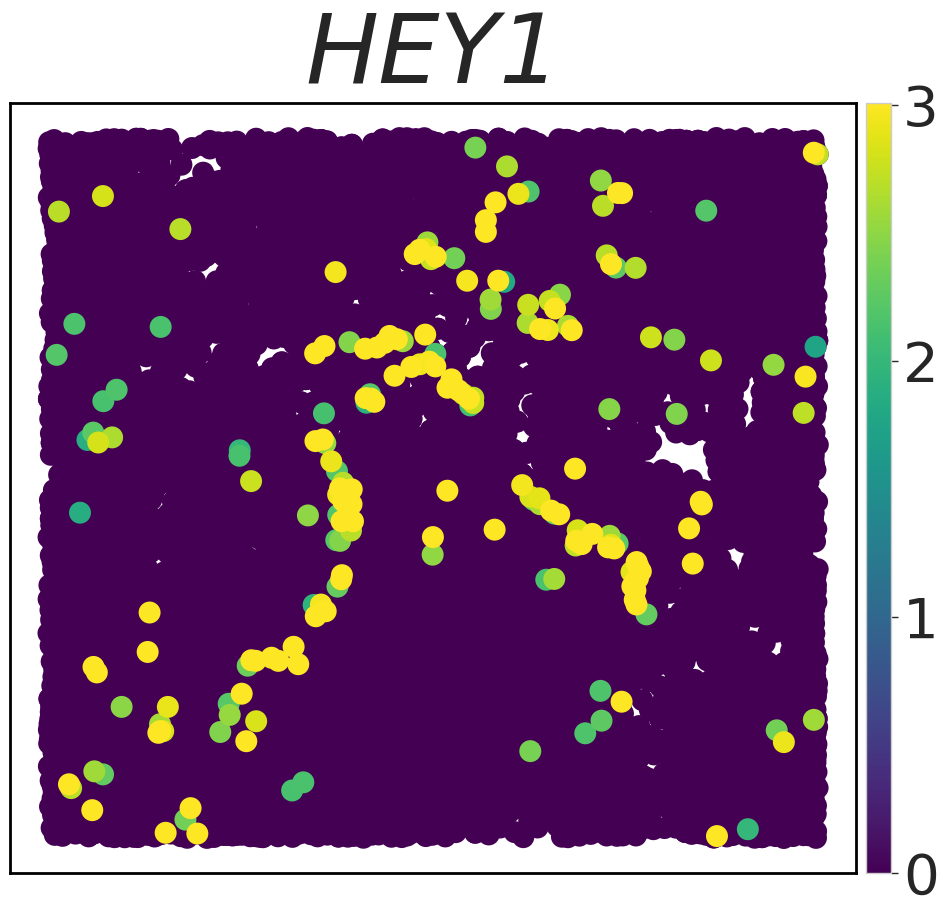

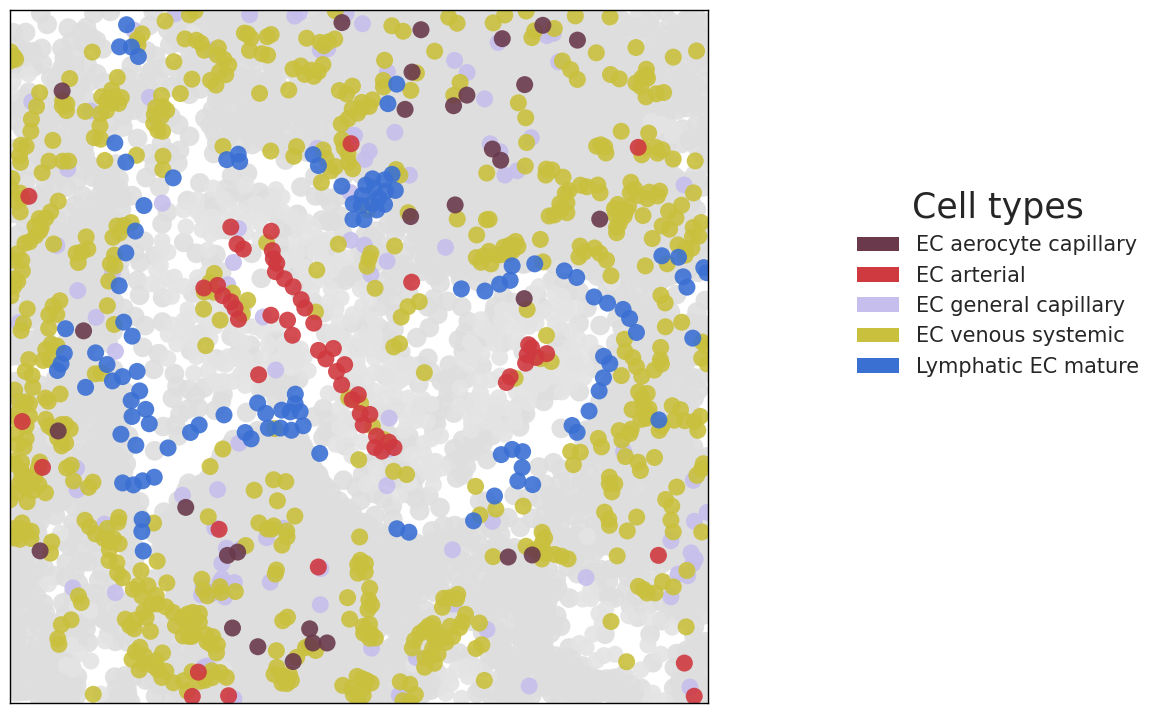

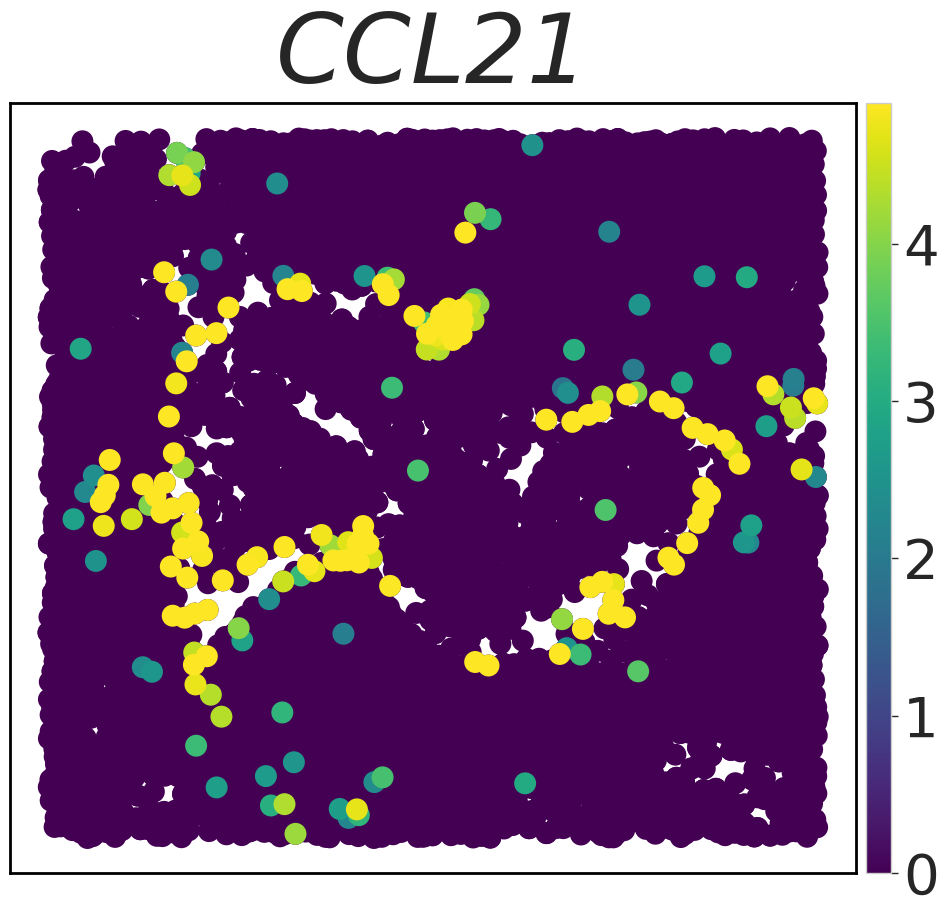

In [8]:
sample = "VUILD107MA"
obs = samples[sample]["obs"]
expression = samples[sample]["marker_expression"]
arterial = select_crop(obs, SAMPLE_CONFIG[sample]["crops"]["arterial"])
lymphatic = select_crop(obs, SAMPLE_CONFIG[sample]["crops"]["lymphatic"])

endothelial_crop_legend = [
    item for item in ENDOTHELIAL_PALETTE.items() if item[0] != "SMCs"
]
endothelial_base_order = [
    "SMCs", "EC general capillary", "EC venous systemic",
    "EC aerocyte capillary",
]
arterial_plot_order = endothelial_base_order + [
    "Lymphatic EC mature", "EC arterial"
]
lymphatic_plot_order = endothelial_base_order + [
    "EC arterial", "Lymphatic EC mature"
]

show_annotation(
    obs, ENDOTHELIAL_PALETTE, "Figure3G_endothelial_full.png",
    (10, 10), 50, 20, legend_anchor=(1.2, 0.7),
    plot_order=arterial_plot_order,
)
show_annotation(
    arterial, ENDOTHELIAL_PALETTE, "Figure3G_arterial_annotation.png",
    (9, 9), 250, 200, legend_items=endothelial_crop_legend,
    plot_order=arterial_plot_order,
)
show_marker(
    arterial, expression, "HEY1", ENDOTHELIAL_PALETTE,
    "Figure3G_arterial_HEY1.png", 1000,
)
show_annotation(
    lymphatic, ENDOTHELIAL_PALETTE, "Figure3G_lymphatic_annotation.png",
    (9, 9), 200, 150, legend_items=endothelial_crop_legend,
    plot_order=lymphatic_plot_order,
)
show_marker(
    lymphatic, expression, "CCL21", ENDOTHELIAL_PALETTE,
    "Figure3G_lymphatic_CCL21.png", 1000,
)

## Figure 3H — fibroblast and mural-cell annotation in IPF lung

`VUILD106MA` is an IPF sample with prominent fibrotic remodeling. The first selected region focuses on extracellular-matrix-producing fibroblasts and is compared with `CTHRC1`. The second focuses on smooth-muscle cells and pericytes and is compared with the contractile marker `ACTA2`. Smooth-muscle cells and pericytes share one color in the manuscript legend because both represent mural compartments in this panel.

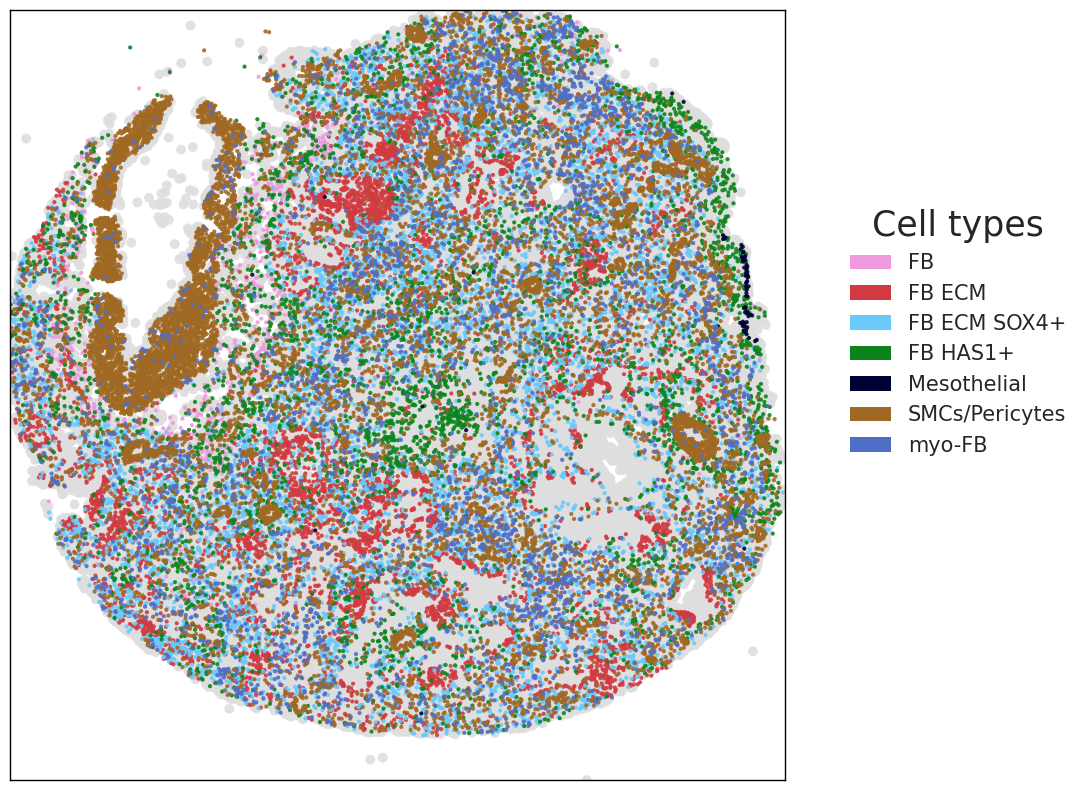

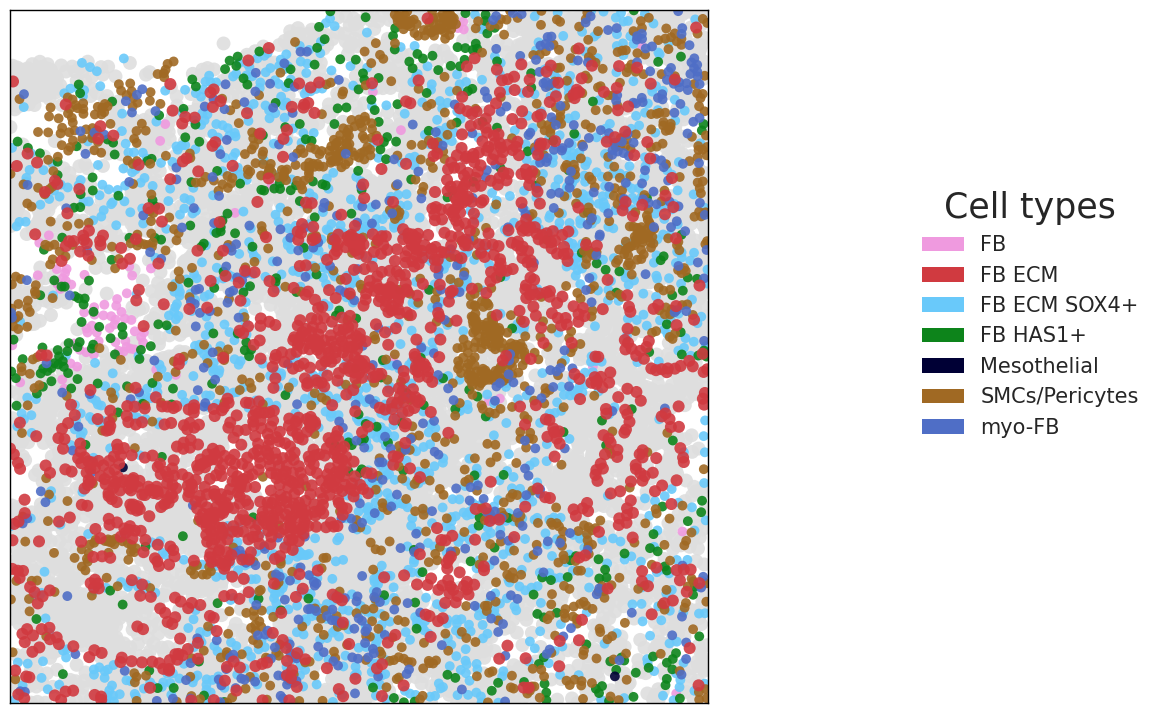

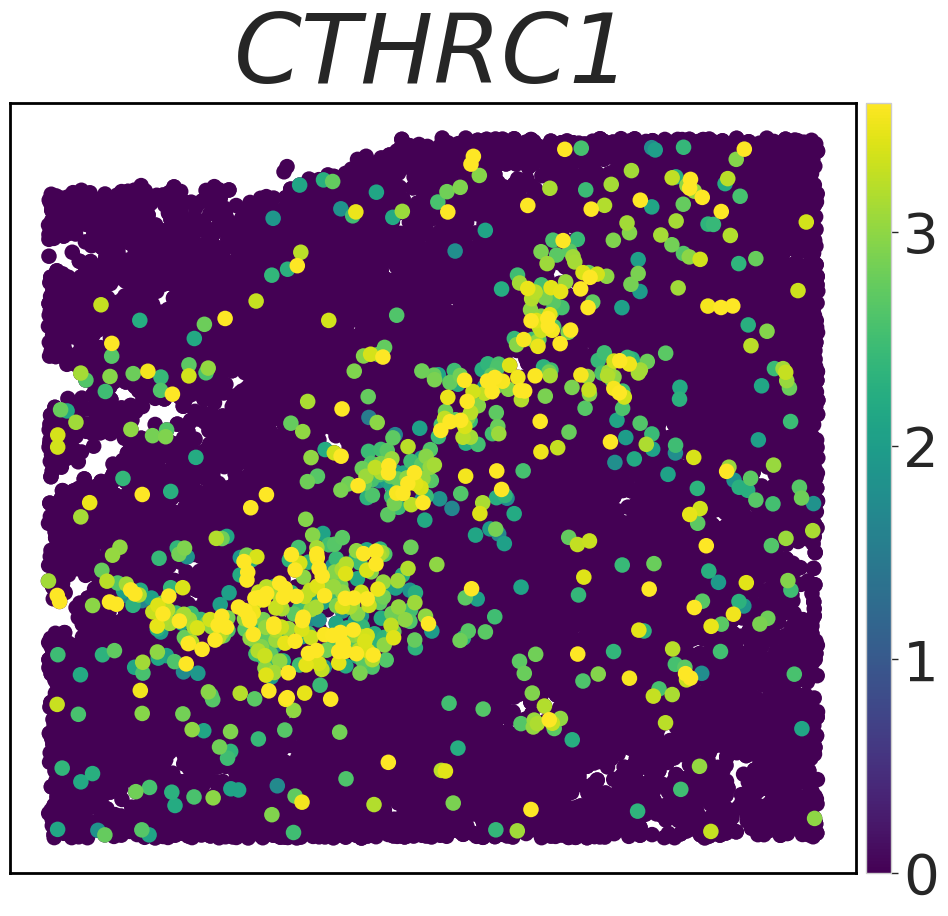

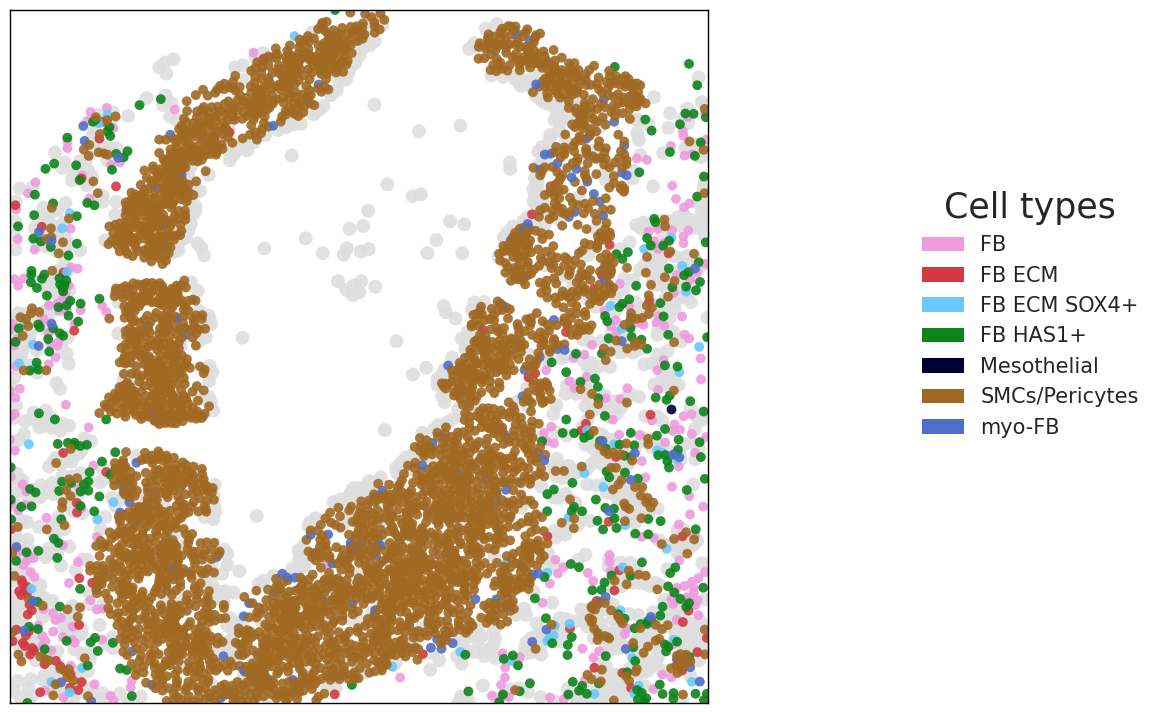

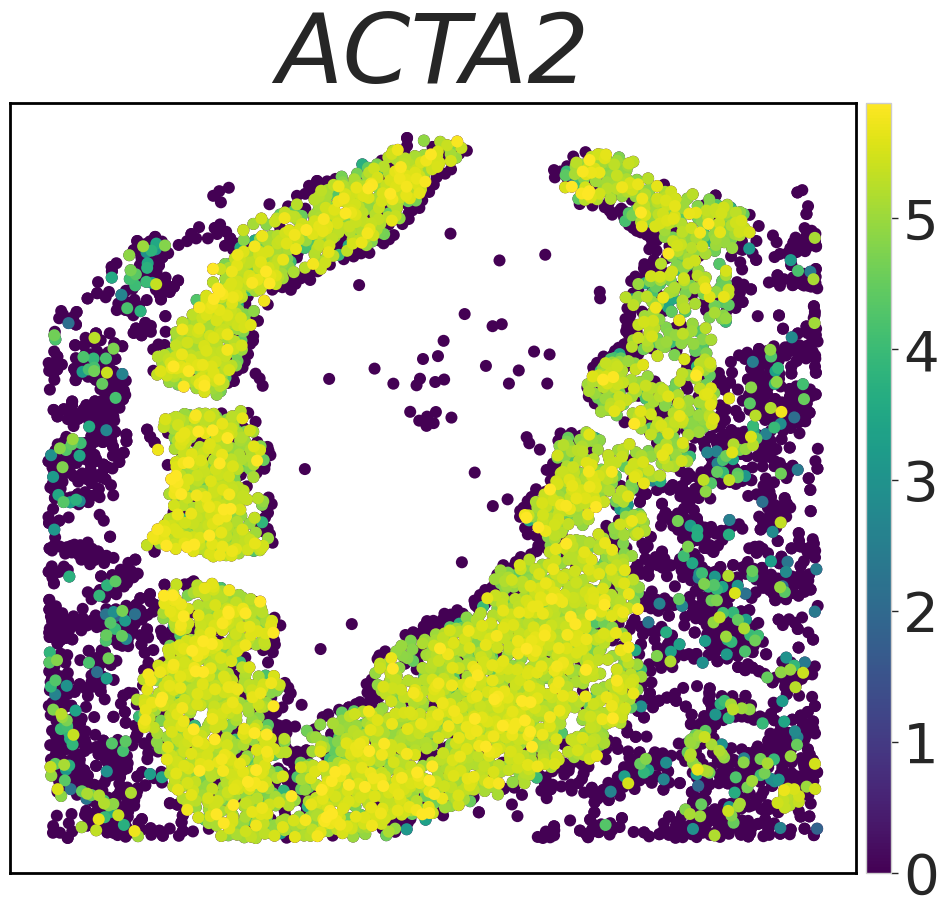

In [9]:
sample = "VUILD106MA"
obs = samples[sample]["obs"]
expression = samples[sample]["marker_expression"]
fibrotic = select_crop(obs, SAMPLE_CONFIG[sample]["crops"]["fibrotic"])
mural = select_crop(obs, SAMPLE_CONFIG[sample]["crops"]["mural"])
fibroblast_legend = [
    ("FB", FIBROBLAST_PALETTE["FB"]),
    ("FB ECM", FIBROBLAST_PALETTE["FB ECM"]),
    ("FB ECM SOX4+", FIBROBLAST_PALETTE["FB ECM SOX4+"]),
    ("FB HAS1+", FIBROBLAST_PALETTE["FB HAS1+"]),
    ("Mesothelial", FIBROBLAST_PALETTE["Mesothelial"]),
    ("SMCs/Pericytes", FIBROBLAST_PALETTE["SMCs"]),
    ("myo-FB", FIBROBLAST_PALETTE["myo-FB"]),
]
fibrotic_plot_order = [
    cell_type for cell_type in FIBROBLAST_PALETTE
    if cell_type != "FB ECM"
] + ["FB ECM"]
mural_plot_order = [
    cell_type for cell_type in FIBROBLAST_PALETTE
    if cell_type != "SMCs"
] + ["SMCs"]

show_annotation(
    obs, FIBROBLAST_PALETTE, "Figure3H_mesenchymal_full.png",
    (10, 10), 50, 9, legend_items=fibroblast_legend,
    legend_anchor=(1.2, 0.7),
)
show_annotation(
    fibrotic, FIBROBLAST_PALETTE, "Figure3H_fibrotic_annotation.png",
    (9, 9), 100, 50, selected_sizes={"FB ECM": 75},
    legend_items=fibroblast_legend,
    plot_order=fibrotic_plot_order,
)
show_marker(
    fibrotic, expression, "CTHRC1", FIBROBLAST_PALETTE,
    "Figure3H_fibrotic_CTHRC1.png", 500,
)
show_annotation(
    mural, FIBROBLAST_PALETTE, "Figure3H_mural_annotation.png",
    (9, 9), 100, 50, legend_items=fibroblast_legend,
    plot_order=mural_plot_order,
)
show_marker(
    mural, expression, "ACTA2", FIBROBLAST_PALETTE,
    "Figure3H_mural_ACTA2.png", 300,
)

## Interpretation and limitations

Across the three examples, spatially coherent atlas assignments coincide with expected expression of epithelial, vascular, and fibrotic marker genes. This agreement supports the use of the PF UGE atlas for transferring cell-state annotations to Xenium data.

These panels are illustrative rather than a formal annotation benchmark. The assignments depend on the composition and labels of the reference atlas, the cosine-neighbor definition, and the selected confidence cutoff. Marker concordance is also not fully independent when related genes contribute to the learned UGE representation. As in the source PF notebooks, cells below the confidence cutoff are omitted from the annotation layers; gray cells are confidently mapped cells outside the highlighted lineage.

In [10]:
print(f"Python: {platform.python_version()}")
print(f"anndata: {ad.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {mpl.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"Completed outputs: {OUTPUT_DIR}")

Python: 3.10.20
anndata: 0.11.4
pandas: 2.3.3
matplotlib: 3.10.8
seaborn: 0.13.2
Completed outputs: UniGeneX/Real_data_PF/outputs/03_spatial_annotation_results
